In [1]:
from IH_main import *
from IH_data_analysis import Insert_Halo_Data_Analysis
import matplotlib.pyplot as plt
import lenstronomy.Util.util as util
import numpy as np

/home/stefan/Documents/uva/Thesis/Coding/main_code/packaging/Insert_Halo_V0.30/sashimi_si.py:228: SyntaxWarning: invalid escape sequence '\s'
  """ Returns Eq. (1.2) of Yang et al. (2023) divided by m.
/home/stefan/Documents/uva/Thesis/Coding/main_code/packaging/Insert_Halo_V0.30/sashimi_si.py:297: SyntaxWarning: invalid escape sequence '\s'
  """ Returns the interpolation function of the effective cross section of SIDM divided by m.


In [2]:
# This notebook is to show the functionality of the latest version (0.30) of Insert_Halo. This notebook shows how to generate host halos and how to
# generate Lenstronomy lensmodels as well as how to compute the convergence from it.
# We start by generating an Insert_Halo class and doing an idle run (as for just the host halo, we do not need to do a full run), then we give the
# base_run data to the Insert_Halo_Data_Analysis class for the lensing part.

IH = Insert_Halo()
IH.run_insert_halo(idle_run = True)
DA = Insert_Halo_Data_Analysis(IH.base_run)

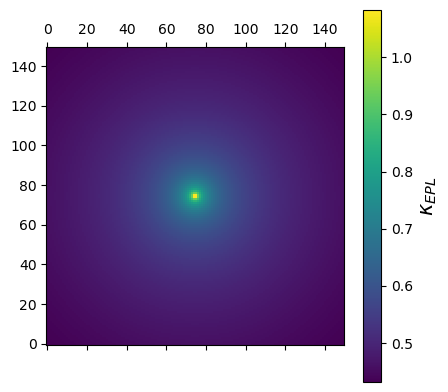

In [3]:
# Here we use prepare_lensmodel to generate a Lenstronomy lensmodel and generate the kwargs for each component. In this case we do this for
# an EPL lensmodel with only the host:

lensmodels = DA.prepare_lensmodel(mass_sheet_correction = False, include_host = True, include_subhalos = False, include_fieldhalos = False)
radius = IH.base_run.SDG.IHB.cone_angle_arcsec / 2
axis_size = 1 / np.sqrt(2) * radius
n_pixels = 150
delta_pixels = axis_size * 2 / n_pixels

x_grid, y_grid = util.make_grid(numPix=n_pixels, deltapix=delta_pixels)
kappa_host = lensmodels["lm_host"].kappa(x_grid, y_grid, lensmodels["kw_host"])
# we make a 2d array out of the 1d grid points
kappa_host_image = util.array2image(kappa_host)

plt.matshow(kappa_host_image, origin='lower')
cbar = plt.colorbar()
cbar.set_label(r'$\kappa_{EPL}$',fontsize=15)
plt.show()

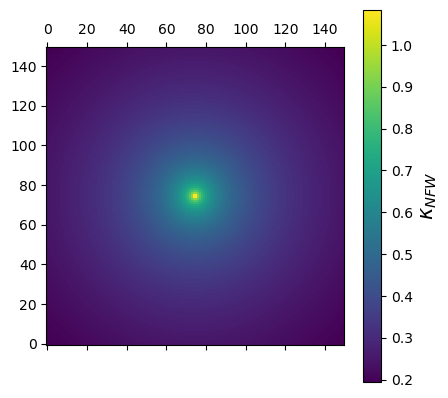

In [4]:
# This is the same as above, but now we assume an NFW profile for the host halo density.

lensmodels = DA.prepare_lensmodel(mass_sheet_correction = False, include_host = True, include_subhalos = False, include_fieldhalos = False,
                                  host_lens_profile = "NFW")
radius = IH.base_run.SDG.IHB.cone_angle_arcsec / 2
axis_size = 1 / np.sqrt(2) * radius
n_pixels = 150
delta_pixels = axis_size * 2 / n_pixels

x_grid, y_grid = util.make_grid(numPix=n_pixels, deltapix=delta_pixels)
kappa_host_NFW = lensmodels["lm_host"].kappa(x_grid, y_grid, lensmodels["kw_host"])
# we make a 2d array out of the 1d grid points
kappa_host_image_NFW = util.array2image(kappa_host_NFW)

plt.matshow(kappa_host_image_NFW, origin='lower')
cbar = plt.colorbar()
cbar.set_label(r'$\kappa_{NFW}$',fontsize=15)
plt.show()

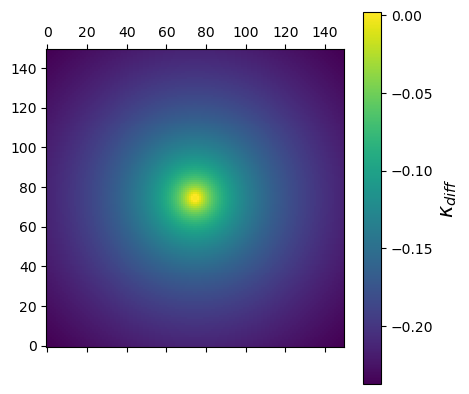

In [5]:
# Showing the difference between the NFW and EPL convergence. As one can see the center (near the Einstein radius) the difference
# is very small and gets larger for larger radii.

kappa_diff = kappa_host_image_NFW - kappa_host_image
plt.matshow(kappa_diff, origin='lower')
cbar = plt.colorbar()
cbar.set_label(r'$\kappa_{diff}$',fontsize=15)
plt.show()

In [6]:
# Now we do a full run to generate substructure

IH = Insert_Halo()
IH.run_insert_halo(idle_run = False)
DA = Insert_Halo_Data_Analysis(IH.base_run)

Calculating subhalo properties: 100%|█████████| 128/128 [00:54<00:00,  2.36it/s]


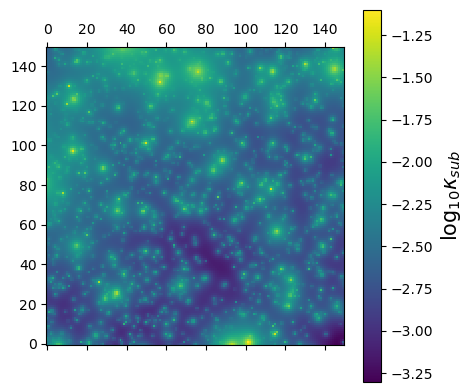

In [7]:
# Here we generate another lensmodel, but only one with substructure with a uniform spatial distribution

lensmodels = DA.prepare_lensmodel(mass_sheet_correction = False, include_host = False, include_subhalos = True, include_fieldhalos = False)
radius = IH.base_run.SDG.IHB.cone_angle_arcsec / 2
axis_size = 1 / np.sqrt(2) * radius
n_pixels = 150
delta_pixels = axis_size * 2 / n_pixels

x_grid, y_grid = util.make_grid(numPix=n_pixels, deltapix=delta_pixels)
#kappa_all = lensmodels["lm_all"].kappa(x_grid, y_grid, lensmodels["kw_all"])
#kappa_host = lensmodels["lm_host"].kappa(x_grid, y_grid, lensmodels["kw_host"])
kappa_sub = lensmodels["lm_sub"].kappa(x_grid, y_grid, lensmodels["kw_sub"])
kappa_sub_image = util.array2image(kappa_sub)

plt.matshow(np.log10(kappa_sub_image), origin='lower')
cbar = plt.colorbar()
cbar.set_label(r'log$_{10}\kappa_{sub}$',fontsize=15)
plt.show()

In [8]:
# Now we do the same thing again, but for an Einasto spatial distribution

IH.rerun_insert_halo(idle_run = False, replace_data = True, spatial = "einasto")
DA = Insert_Halo_Data_Analysis(IH.base_run)

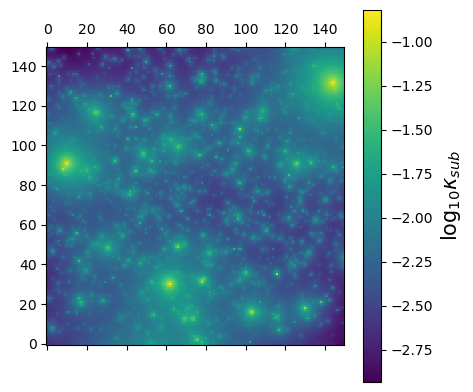

In [9]:
# The maximum convergence is slightly higher here (take note that the convergence plotted is on a logarithmic scale

lensmodels = DA.prepare_lensmodel(mass_sheet_correction = False, include_host = False, include_subhalos = True, include_fieldhalos = False)
radius = IH.base_run.SDG.IHB.cone_angle_arcsec / 2
axis_size = 1 / np.sqrt(2) * radius
n_pixels = 150
delta_pixels = axis_size * 2 / n_pixels

x_grid, y_grid = util.make_grid(numPix=n_pixels, deltapix=delta_pixels)
#kappa_all = lensmodels["lm_all"].kappa(x_grid, y_grid, lensmodels["kw_all"])
#kappa_host = lensmodels["lm_host"].kappa(x_grid, y_grid, lensmodels["kw_host"])
kappa_sub = lensmodels["lm_sub"].kappa(x_grid, y_grid, lensmodels["kw_sub"])
kappa_sub_image = util.array2image(kappa_sub)

plt.matshow(np.log10(kappa_sub_image), origin='lower')
cbar = plt.colorbar()
cbar.set_label(r'log$_{10}\kappa_{sub}$',fontsize=15)
plt.show()